In [13]:
import pandas as pd
import numpy as np
import wfdb
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
def load_and_prepare_data(base_path, sampling_rate=100):
    """
    PTB-XL verilerini yükler, meta verileri işler ve süper sınıfları ekler.
    """
    db_path = os.path.join(base_path, 'ptbxl_database.csv')
    df = pd.read_csv(db_path, index_col='ecg_id')

    df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))
    df['filename'] = df.filename_hr if sampling_rate == 500 else df.filename_lr
    df['filepath'] = df.filename.apply(lambda x: os.path.join(base_path, x))

    scp_path = os.path.join(base_path, 'scp_statements.csv')
    agg_df = pd.read_csv(scp_path, index_col=0)
    agg_df = agg_df[agg_df.diagnostic == 1]

    def aggregate_diagnostic(y_dic):
        tmp = []
        for key in y_dic.keys():
            if key in agg_df.index:
                tmp.append(agg_df.loc[key].diagnostic_class)
        return list(set(tmp))

    df['superdiagnostic'] = df.scp_codes.apply(aggregate_diagnostic)
    
    df_filtered = df[df.superdiagnostic.apply(lambda x: len(x) > 0)].copy()
    
    if df_filtered.empty:
        return None

    df_filtered['main_diagnostic'] = df_filtered.superdiagnostic.apply(lambda x: x[0])

    target_classes = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
    df_final = df_filtered[df_filtered.main_diagnostic.isin(target_classes)].copy()
    
    return df_final

In [22]:
DATA_PATH = '../data/raw'

df_meta = load_and_prepare_data(DATA_PATH, sampling_rate=100)

if df_meta is not None:
    print("\nVeri seti başarıyla yüklendi ve işlendi.")
else:
    print("\nVeri yükleme sırasında bir hata oluştu.")

✔️ '../data/raw/ptbxl_database.csv' başarıyla yüklendi.
✔️ '../data/raw/scp_statements.csv' başarıyla yüklendi. 44 diagnostik kod bulundu.
✔️ Hedef 5 sınıfa göre filtrelendi. Son kayıt sayısı: 21388

✅ Veri seti başarıyla yüklendi ve işlendi.


In [21]:
if df_meta is not None:
    print("\n--- b) Veri Kümesine Genel Bakış ---")
    print(f"Kayıt Sayısı: {len(df_meta)}")
    print(f"Metadata Özellik Sayısı: {len(df_meta.columns)}")
    print(f"Hedef Sınıfların Sayısı: {df_meta['main_diagnostic'].nunique()}")

    print("\nSınıf Başına Örnek Sayısı:")
    print(df_meta['main_diagnostic'].value_counts())

    print("\nEksik (NULL) Değer Sayısı (Metadata):")
    print(df_meta.isnull().sum())

    non_numeric_features = df_meta.select_dtypes(include=['object', 'category']).columns.tolist()
    non_numeric_features.extend(['scp_codes', 'superdiagnostic'])
    print(f"\nSayısal Olmayan Özellikler: {non_numeric_features}")


--- b) Veri Kümesine Genel Bakış ---
Kayıt Sayısı: 21388
Metadata Özellik Sayısı: 31
Hedef Sınıfların Sayısı: 5

Sınıf Başına Örnek Sayısı:
main_diagnostic
NORM    9071
MI      5469
STTC    3563
CD      2750
HYP      535
Name: count, dtype: int64

Eksik (NULL) Değer Sayısı (Metadata):
patient_id                          0
age                                 0
sex                                 0
height                          14470
weight                          12022
nurse                            1439
site                               16
device                              0
recording_date                      0
report                              0
scp_codes                           0
heart_axis                       8160
infarction_stadium1             15788
infarction_stadium2             21285
validated_by                     9092
second_opinion                      0
initial_autogenerated_report        0
validated_by_human                  0
baseline_drift               


--- c) Kategorik Özellik Dağılımı ---


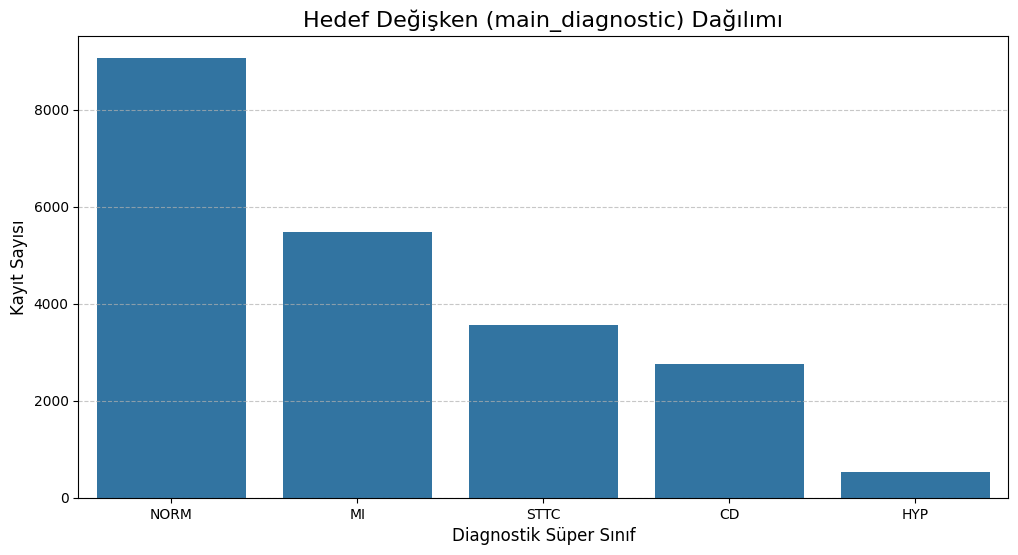

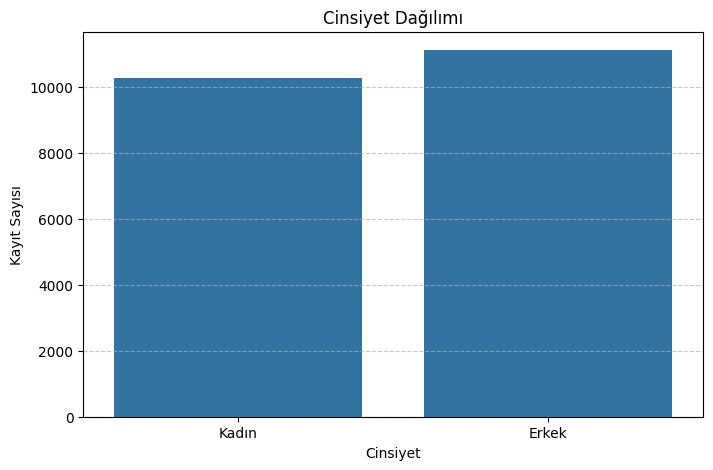

In [17]:
if df_meta is not None:
    print("\n--- c) Kategorik Özellik Dağılımı ---")
    
    # 1. Hedef Değişken (main_diagnostic) Dağılımı
    plt.figure(figsize=(12, 6))
    sns.countplot(x='main_diagnostic', data=df_meta, order=df_meta['main_diagnostic'].value_counts().index)
    plt.title('Hedef Değişken (main_diagnostic) Dağılımı', fontsize=16)
    plt.xlabel('Diagnostik Süper Sınıf', fontsize=12)
    plt.ylabel('Kayıt Sayısı', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # 2. Cinsiyet Dağılımı
    plt.figure(figsize=(8, 5))
    # Cinsiyet 0: Erkek, 1: Kadın olarak kodlanmış
    sns.countplot(x=df_meta['sex'].map({0: 'Erkek', 1: 'Kadın'}))
    plt.title('Cinsiyet Dağılımı')
    plt.xlabel('Cinsiyet')
    plt.ylabel('Kayıt Sayısı')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [18]:
if df_meta is not None:
    print("\n--- d) Sayısal Özellik İstatistiği (Metadata) ---")
    numeric_stats = df_meta[['age', 'height', 'weight']].describe()
    print(numeric_stats.loc[['mean', 'min', 'max']])


--- d) Sayısal Özellik İstatistiği (Metadata) ---
             age      height    weight
mean   62.608753  166.694565   71.0205
min     2.000000    6.000000    5.0000
max   300.000000  209.000000  250.0000



--- h) Korelasyon Analizi (Metadata) ---


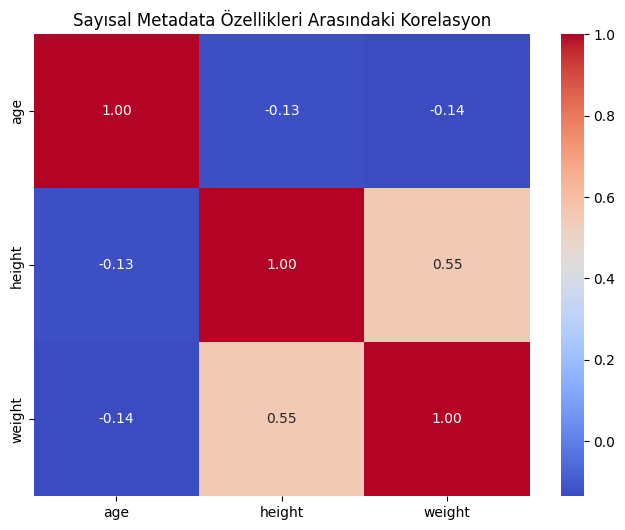

In [19]:
if df_meta is not None:
    print("\n--- h) Korelasyon Analizi (Metadata) ---")
    correlation_matrix = df_meta[['age', 'height', 'weight']].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Sayısal Metadata Özellikleri Arasındaki Korelasyon')
    plt.show()


--- Örnek Sinyal Görselleştirme ---


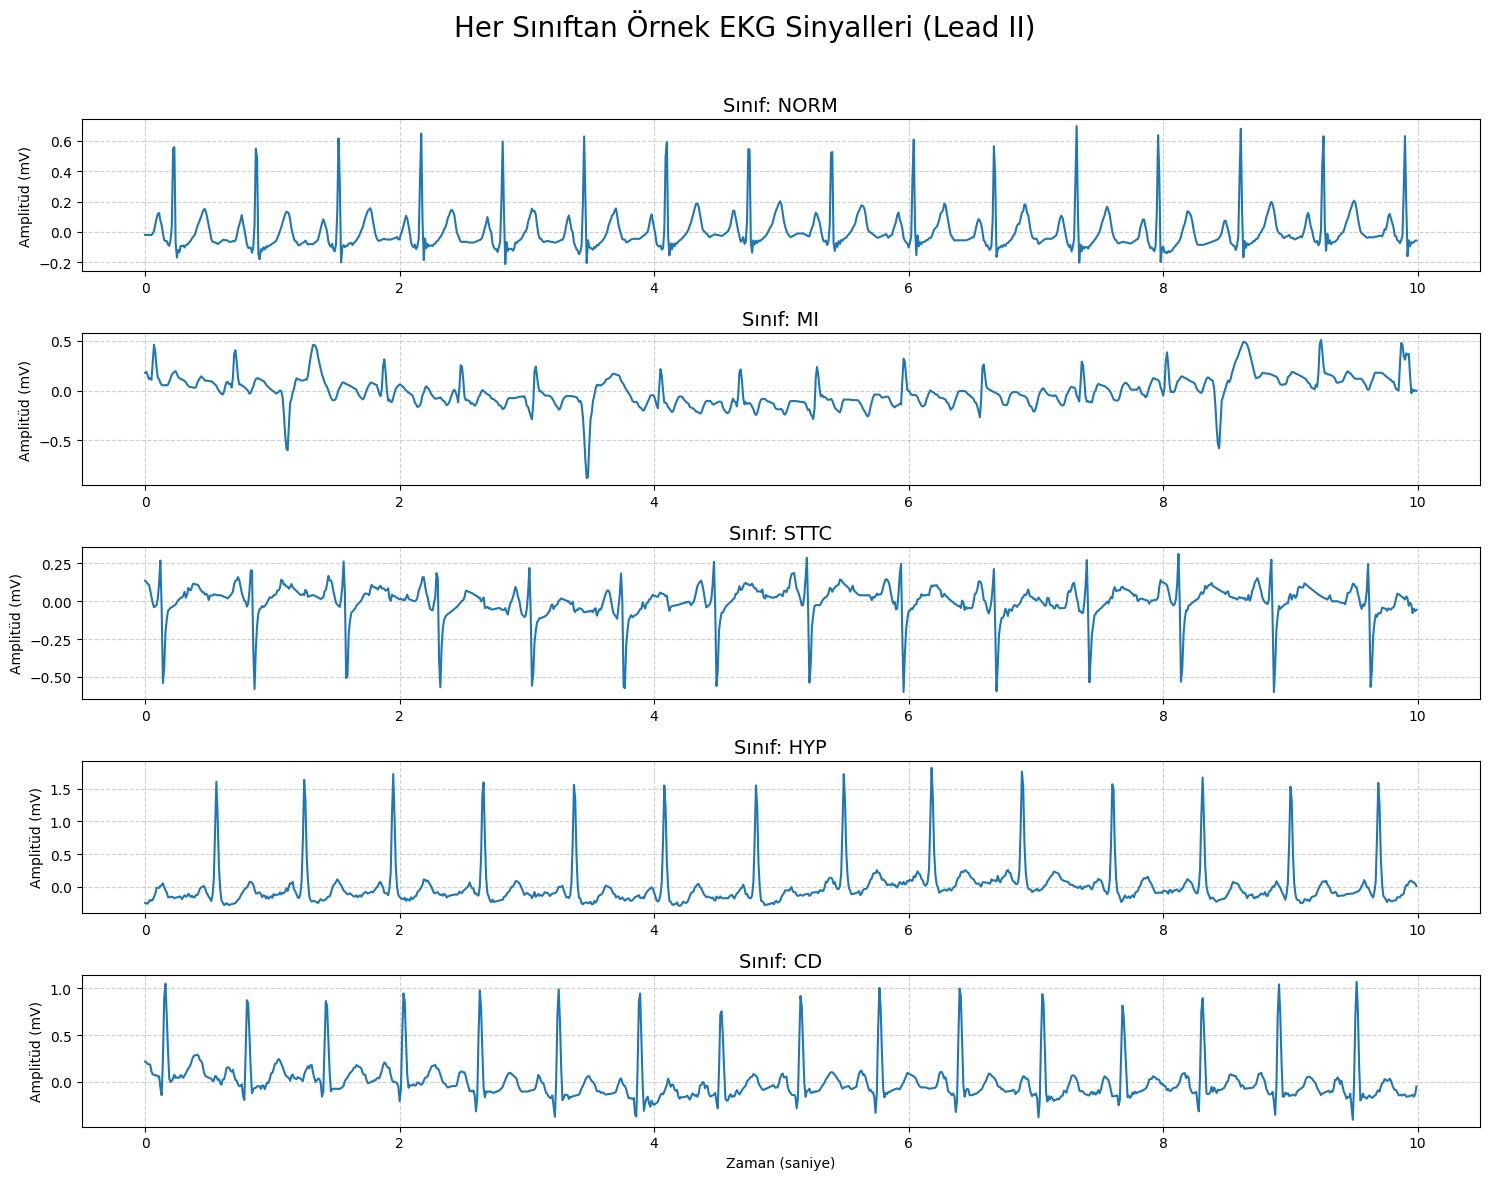

In [20]:
if df_meta is not None:
    print("\n--- Örnek Sinyal Görselleştirme ---")
    
    def plot_example_signals(df, sampling_rate=100):
        leads = ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
        target_classes = df['main_diagnostic'].unique()
        
        fig, axs = plt.subplots(len(target_classes), 1, figsize=(15, 12))
        fig.suptitle('Her Sınıftan Örnek EKG Sinyalleri (Lead II)', fontsize=20)

        for i, diag_class in enumerate(target_classes):
            sample = df[df['main_diagnostic'] == diag_class].sample(1, random_state=42)
            filepath = sample.filepath.values[0]
            
            signal, meta = wfdb.rdsamp(filepath.replace('.dat', ''))
            
            lead_index = leads.index('II')
            lead_signal = signal[:, lead_index]
            
            time = np.arange(len(lead_signal)) / sampling_rate
            
            axs[i].plot(time, lead_signal)
            axs[i].set_title(f'Sınıf: {diag_class}', fontsize=14)
            axs[i].set_ylabel('Amplitüd (mV)')
            axs[i].grid(linestyle='--', alpha=0.6)

        axs[-1].set_xlabel('Zaman (saniye)')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    plot_example_signals(df_meta)

--- GRAFİK ŞU SIRALAMA İLE ÇİZİLİYOR: ['CD', 'HYP', 'MI', 'NORM', 'STTC'] ---


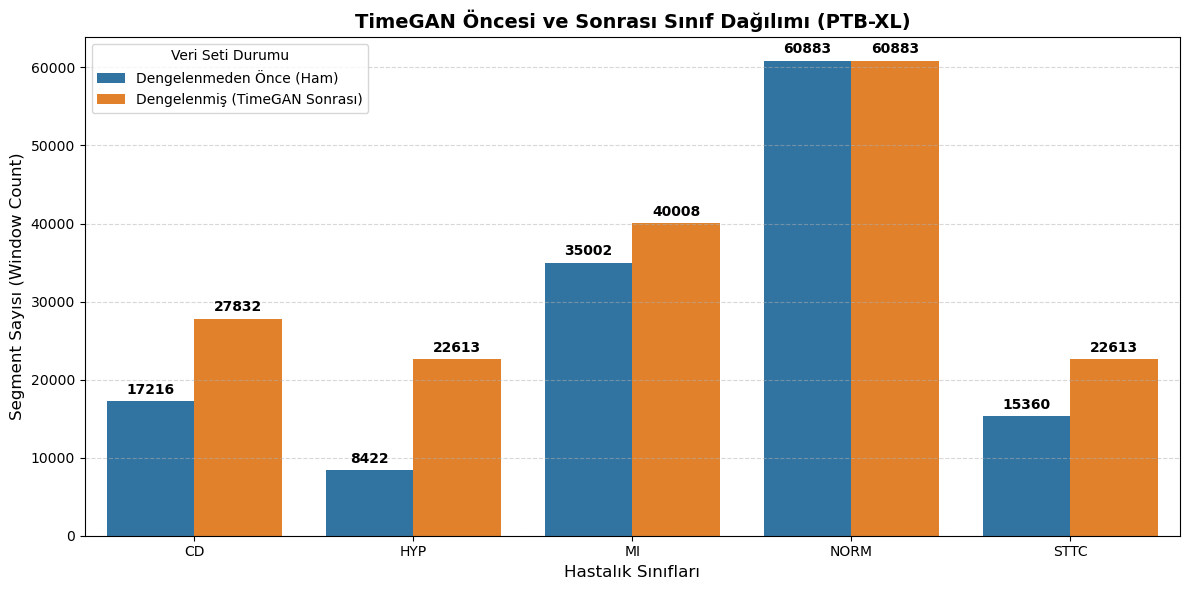

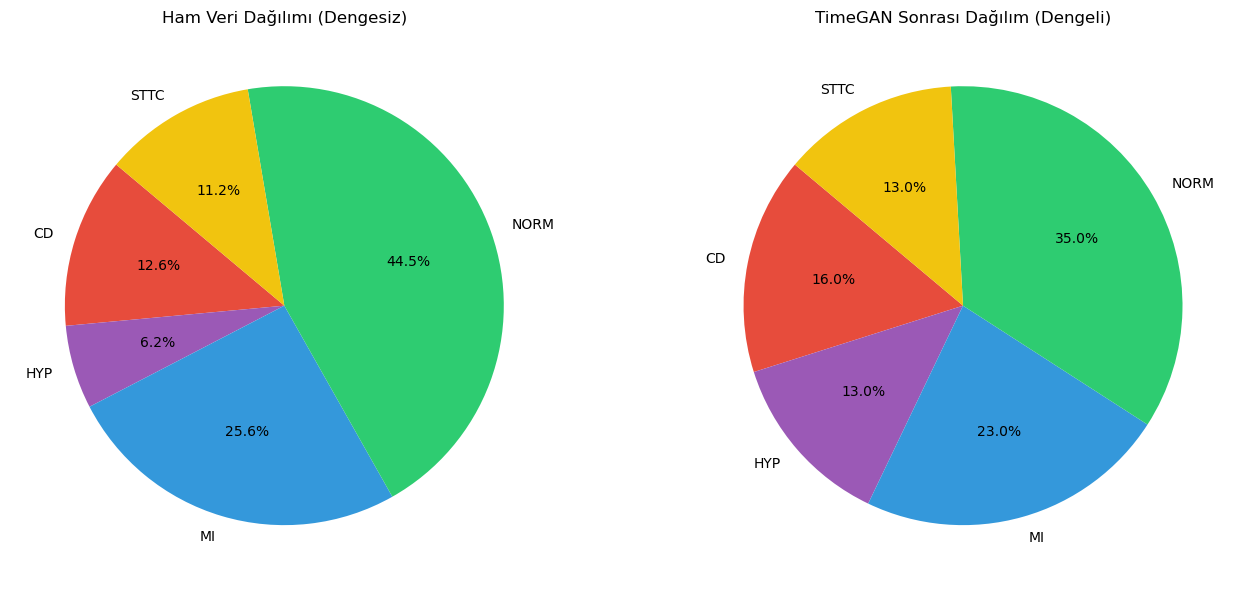

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. AYARLAR ---
BASE_PATH = r'F:\repo\bitirme-projesi\data\processed'

# === KESİNLEŞMİŞ SIRALAMA (0'dan 4'e) ===
# 0:CD, 1:HYP, 2:MI, 3:NORM, 4:STTC
CLASS_NAMES = ['CD', 'HYP', 'MI', 'NORM', 'STTC']
# ========================================

file_orig = os.path.join(BASE_PATH, 'y_train.npy')
file_bal  = os.path.join(BASE_PATH, 'y_train_balanced.npy')

print(f"--- GRAFİK ŞU SIRALAMA İLE ÇİZİLİYOR: {CLASS_NAMES} ---")

# Verileri Yükle
y_orig = np.load(file_orig)
y_bal = np.load(file_bal)

# Sayıları Hesapla
unique_orig, counts_orig = np.unique(y_orig, return_counts=True)
unique_bal, counts_bal = np.unique(y_bal, return_counts=True)
counts_orig_dict = dict(zip(unique_orig, counts_orig))
counts_bal_dict  = dict(zip(unique_bal, counts_bal))

# Grafik İçin Veri Hazırla
plot_data = []
for i, class_name in enumerate(CLASS_NAMES):
    # Orijinal (Mavi)
    plot_data.append({
        'Sınıf': class_name,
        'Adet': counts_orig_dict.get(i, 0),
        'Durum': 'Dengelenmeden Önce (Ham)'
    })
    # Dengeli (Turuncu)
    plot_data.append({
        'Sınıf': class_name,
        'Adet': counts_bal_dict.get(i, 0),
        'Durum': 'Dengelenmiş (TimeGAN Sonrası)'
    })

df_plot = pd.DataFrame(plot_data)

# --- GÖRSELLEŞTİRME ---
plt.figure(figsize=(12, 6))

# Renk Paleti (Mavi - Turuncu)
custom_palette = ['#1f77b4', '#ff7f0e']

ax = sns.barplot(
    data=df_plot, 
    x='Sınıf', 
    y='Adet', 
    hue='Durum', 
    palette=custom_palette
)

plt.title('TimeGAN Öncesi ve Sonrası Sınıf Dağılımı (PTB-XL)', fontsize=14, fontweight='bold')
plt.xlabel('Hastalık Sınıfları', fontsize=12)
plt.ylabel('Segment Sayısı (Window Count)', fontsize=12) # Burayı düzelttim çünkü bunlar segment
plt.legend(title='Veri Seti Durumu')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Barların üzerine sayıları yaz
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# --- PASTA GRAFİĞİ (ORANLAR) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Renkler (Sınıflara özel sabit renkler olsun ki karışmasın)
# CD, HYP, MI, NORM, STTC
colors = ['#e74c3c', '#9b59b6', '#3498db', '#2ecc71', '#f1c40f'] 

# 1. Ham Veri
axes[0].pie([counts_orig_dict.get(i, 0) for i in range(5)], 
            labels=CLASS_NAMES, autopct='%1.1f%%', startangle=140, colors=colors)
axes[0].set_title('Ham Veri Dağılımı (Dengesiz)')

# 2. Dengeli Veri
axes[1].pie([counts_bal_dict.get(i, 0) for i in range(5)], 
            labels=CLASS_NAMES, autopct='%1.1f%%', startangle=140, colors=colors)
axes[1].set_title('TimeGAN Sonrası Dağılım (Dengeli)')

plt.tight_layout()
plt.show()